In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Index(['Country', 'Region', 'Population', 'Area (sq. mi.)',
       'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
       'Net migration', 'Infant mortality (per 1000 births)',
       'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)',
       'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate',
       'Agriculture', 'Industry', 'Service'],
      dtype='object')


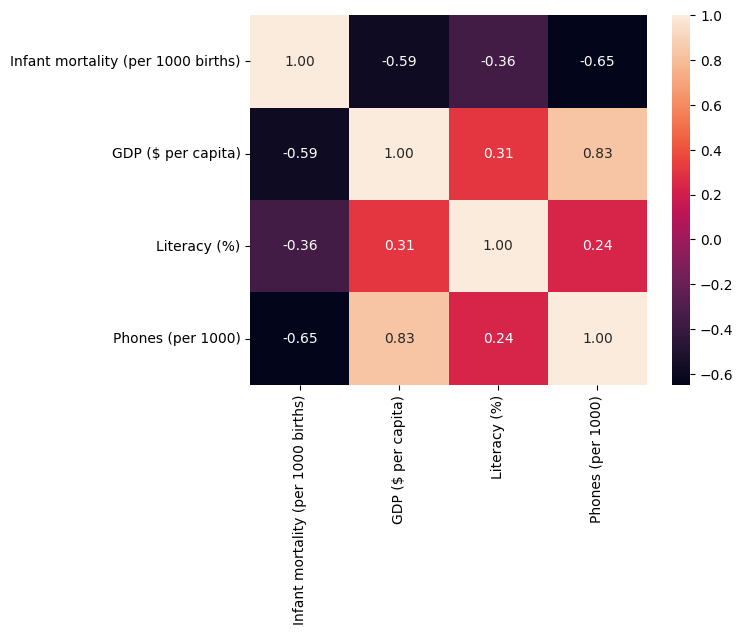

In [28]:
ds_paises = pd.read_csv('paises (2).csv', delimiter=';')
print(ds_paises.columns)

#selecionando as colunas que quero identificar uma correlação
corr = ds_paises[['Infant mortality (per 1000 births)', 'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)']].corr()
#tracando o heatmap
sns.heatmap(
    corr,
    annot = True,
    fmt = '.2f'
)
plt.show()

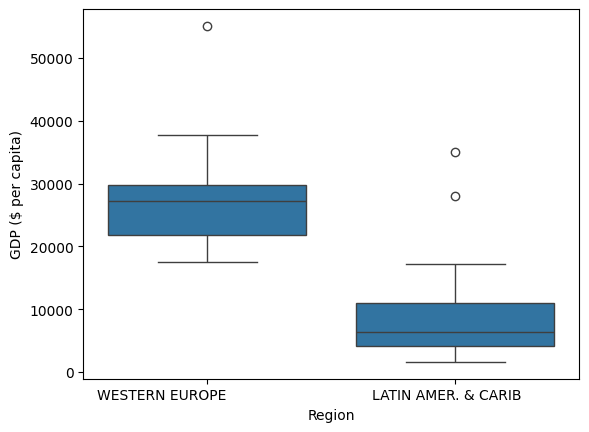

In [26]:
cond = ds_paises['Region'].str.strip() == 'WESTERN EUROPE'
paises_europeus = ds_paises[cond]

cond1 = ds_paises['Region'].str.strip() == 'LATIN AMER. & CARIB'
paises_latinos = ds_paises[cond1]

# Juntar os dois grupos
paises_comparados = pd.concat([paises_europeus, paises_latinos])

# Criar o boxplot
sns.boxplot(
    data=paises_comparados,
    x='Region',
    y='GDP ($ per capita)'
)

plt.show()

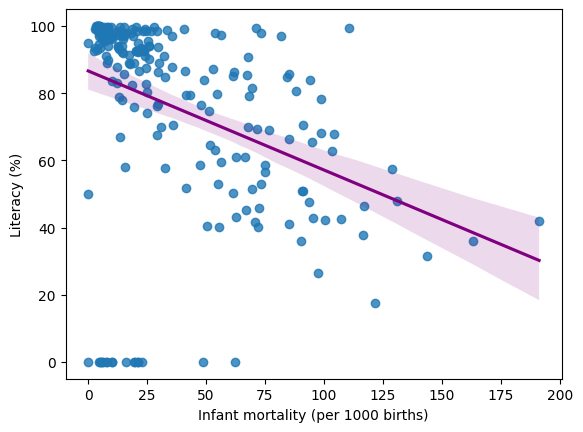

In [31]:
sns.regplot(
    data = ds_paises,
    x = 'Infant mortality (per 1000 births)',
    y = 'Literacy (%)',
    line_kws = {'color':'purple'} #essa linha traçada no meio ajuda a verificar a tendência dos dados
)
plt.show()

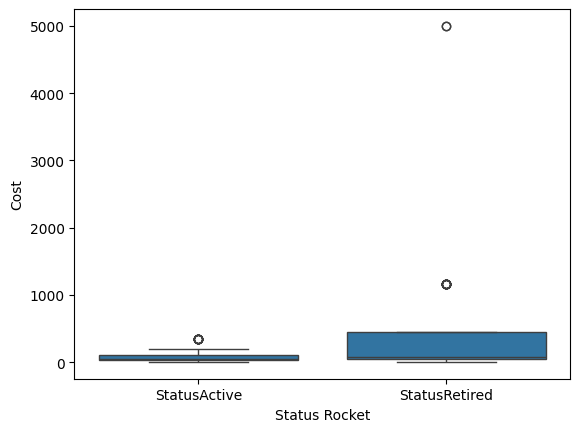

In [42]:
ds_space = pd.read_csv('space.csv', delimiter=';')
#print(ds_space.columns)

ds_space.columns = ds_space.columns.str.strip()

cond = ds_space['Cost'].astype(float) > 0
ds_space = ds_space[cond] ####


cond1 = ds_space['Status Rocket'] == 'StatusRetired'
statusretired = ds_space[cond1]

cond2 = ds_space['Status Rocket'] == 'StatusActive'
statusactive = ds_space[cond2]

# Juntar os dois grupos
together = pd.concat([statusactive, statusretired])

# Criar o boxplot
sns.boxplot(
    data=together,
    x='Status Rocket',
    y='Cost'
)

plt.show()